# Skincare Recommendation System — Demo
This notebook imports the modular pipeline and runs demos + evaluation.

## Setup

In [1]:
# Use GitHub as "source of truth" for all .py files (pipeline, data_loader, agents)
# Colab does not automatically have our code, so we need to bring it in.
import os

# If repo is not already downloaded in this Colab session, clone it
if not os.path.exists("/content/skincare-recommendation-system"):
    !git clone https://github.com/jenniiiiiii007S/skincare-recommendation-system.git

# Move into repo folder so Python can import .py files
%cd /content/skincare-recommendation-system
# Always pull latest changes from GitHub so we are using recent version of .py files
!git pull

/content/skincare-recommendation-system
Already up to date.


In [2]:
!pip install chromadb google-genai

In [3]:
from google import genai
from google.colab import userdata

# Initialize Gemini client
api_key = userdata.get('GEMINI_API_KEY')
client = genai.Client(api_key=api_key)

# Import pipeline from GitHub repo
from pipeline import full_pipeline, baseline_gemini

print("Setup complete.")

Setup complete.


## Load Data & Build Vector Database

In [4]:
from data_loader import load_and_clean_data, build_vector_database

products_df, inci_df = load_and_clean_data()
product_collection, ingredient_collection = build_vector_database(products_df, inci_df)

Loaded 2418 products and 248 ingredients.
Indexed 2418 products and 248 ingredients.


## Test Agent 1: Skin Profile Agent

In [5]:
import json
from agents.skin_profile import skin_profile_agent

test_input = "I have oily acne-prone skin and I am allergic to fragrance. Looking for a full routine."
profile = skin_profile_agent(client, test_input)
print(json.dumps(profile, indent=2))

{
  "skin_type": "oily",
  "concerns": [
    "acne"
  ],
  "allergies": [
    "fragrance"
  ],
  "age": null,
  "current_products": [],
  "goals": [],
  "routine_request": "full routine",
  "image_observations": null
}


## Test Agent 2: Product Retrieval Agent

In [6]:
from agents.retrieval import search_products

results = search_products(product_collection, "gentle cleanser for oily acne-prone skin", product_type="Cleanser")

for i in range(len(results['ids'][0])):
    meta = results['metadatas'][0][i]
    distance = results['distances'][0][i]
    print(f"{i+1}. {meta['name']}")
    print(f"   Brand: {meta['brand']} | Type: {meta['product_type']} | Price: {meta['price']}")
    print(f"   Relevance: {1 - distance:.3f}")
    print()

1. Acne Solutions Clarifying Lotion
   Brand: CLINIQUE | Type: Cleanser | Price: $17.0
   Relevance: 0.528

2. EradiKate® Daily Cleanser Acne Treatment
   Brand: KATE SOMERVILLE | Type: Cleanser | Price: $38.0
   Relevance: 0.527

3. Cleanser
   Brand: EVE LOM | Type: Cleanser | Price: $80.0
   Relevance: 0.521

4. Avène Cleanance Cleansing Gel 200ml
   Brand: Avène Cleanance | Type: Cleanser | Price: $16.2
   Relevance: 0.519

5. Make-Up Removing Cleansing Oil
   Brand: CAUDALIE | Type: Cleanser | Price: $28.0
   Relevance: 0.518



## Test Agent 3: Budget Constraint

In [7]:
from agents.budget_agent import budget_agent, filter_products_by_budget, format_budget_for_prompt
from agents.retrieval import search_products

# Test 1: No budget mentioned
print("=" * 60)
print("Test 1: No budget mentioned")
print("=" * 60)
test_input_1 = "I have oily acne-prone skin and want a full routine."
profile_1 = budget_agent(client, test_input_1)
print(json.dumps(profile_1, indent=2))

# Test 2: Tier-based budget
print("\n" + "=" * 60)
print("Test 2: Tier-based budget (drugstore)")
print("=" * 60)
test_input_2 = "I want a cheap drugstore routine for oily skin."
profile_2 = budget_agent(client, test_input_2)
print(json.dumps(profile_2, indent=2))

# Test 3: Specific overall dollar amount
print("\n" + "=" * 60)
print("Test 3: Specific overall limit")
print("=" * 60)
test_input_3 = "Build me a routine but keep the whole thing under $120."
profile_3 = budget_agent(client, test_input_3)
print(json.dumps(profile_3, indent=2))

# Test 4: Per-category limits
print("\n" + "=" * 60)
print("Test 4: Per-category limits")
print("=" * 60)
test_input_4 = "I'd spend $60 on a serum, keep cleanser under $15, and sunscreen no more than $25."
profile_4 = budget_agent(client, test_input_4)
print(json.dumps(profile_4, indent=2))

# Test 5: Mixed qualitative + numeric
print("\n" + "=" * 60)
print("Test 5: Mixed qualitative and numeric")
print("=" * 60)
test_input_5 = "Drugstore cleanser please, but I will splurge on moisturizer up to $100."
profile_5 = budget_agent(client, test_input_5)
print(json.dumps(profile_5, indent=2))

# Test 6: Run the budget filter on REAL retrieved products from ChromaDB
print("\n" + "=" * 60)
print("Test 6: Filter real retrieved products against per-category budget")
print("=" * 60)

# Pull real candidates from each product type
product_types = ["Cleanser", "Serum", "Moisturizer", "Sun protect"]
real_products = []

for ptype in product_types:
    results = search_products(
        product_collection,
        f"{ptype.lower()} for oily acne-prone skin",
        n_results=5,
        product_type=ptype,
        skin_type="oily"
    )
    for i in range(len(results["ids"][0])):
        meta = results["metadatas"][0][i]
        real_products.append({
            "name": meta["name"],
            "brand": meta["brand"],
            "product_type": meta["product_type"],
            "ingredients": results["documents"][0][i],
            "price": meta["price"],
        })

print(f"Retrieved {len(real_products)} real products from ChromaDB:\n")
for p in real_products:
    print(f"  {p['product_type']:14} | {p['price']:8} | {p['name']}")

# Apply the per-category budget profile from Test 4
print("\nApplying budget profile from Test 4:")
print(format_budget_for_prompt(profile_4))

filtered = filter_products_by_budget(real_products, profile_4)
print(f"\n{len(filtered)} of {len(real_products)} products passed the budget filter:")
for p in filtered:
    print(f"  {p['product_type']:14} | {p['price']:8} | {p['name']}")

fallbacks = getattr(filter_products_by_budget, "last_fallbacks", [])
if fallbacks:
    print(f"\nFallbacks used (no in-budget option, cheapest available kept):")
    for fb in fallbacks:
        print(f"  - {fb['product_type']}: {fb['product_name']} at ${fb['actual_price']} "
              f"(user limit was ${int(fb['user_limit'])})")
else:
    print("\nAll categories had at least one in-budget product.")

# Test 7: Tight budget on real products to force fallbacks
print("\n" + "=" * 60)
print("Test 7: Aggressive tier budget on real products (expect fallbacks)")
print("=" * 60)
test_input_7 = "I have $30 total to spend on my whole routine."
profile_7 = budget_agent(client, test_input_7)
print("Detected budget profile:")
print(json.dumps(profile_7, indent=2))

filtered_strict = filter_products_by_budget(real_products, profile_7)
print(f"\n{len(filtered_strict)} of {len(real_products)} products passed (including fallbacks):")
for p in filtered_strict:
    print(f"  {p['product_type']:14} | {p['price']:8} | {p['name']}")

fallbacks_strict = getattr(filter_products_by_budget, "last_fallbacks", [])
if fallbacks_strict:
    print(f"\nFallbacks used (no cheaper alternatives exist):")
    for fb in fallbacks_strict:
        print(f"  - {fb['product_type']}: {fb['product_name']} at ${fb['actual_price']} "
              f"(user limit was ${int(fb['user_limit'])})")

    # Simulate what pipeline.py does — attach fallbacks to the budget profile
    profile_7["budget_fallbacks"] = fallbacks_strict
    print("\nUpdated budget summary as it would appear in the routine builder prompt:")
    print(format_budget_for_prompt(profile_7))
else:
    print("\nAll categories had at least one in-budget product.")

Test 1: No budget mentioned
{
  "overall_limit": null,
  "tier": "any",
  "per_category": {
    "Cleanser": null,
    "Serum": null,
    "Moisturizer": null,
    "Sun protect": null,
    "Retinol": null,
    "Face oil": null
  },
  "raw_mention": null
}

Test 2: Tier-based budget (drugstore)
{
  "overall_limit": null,
  "tier": "under_50",
  "per_category": {
    "Cleanser": null,
    "Serum": null,
    "Moisturizer": null,
    "Sun protect": null,
    "Retinol": null,
    "Face oil": null
  },
  "raw_mention": "cheap drugstore routine"
}

Test 3: Specific overall limit
[budget_agent] Gemini call failed: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
{
  "overall_limit": null,
  "tier": "any",
  "per_category": {
    "Cleanser": null,
    "Serum": null,
    "Moisturizer": null,
    "Sun protect": null,
    "Retinol": null,
    "Face oil": n

## Test Agent 4: Conflict Checker

In [8]:
from agents.conflict_checker import conflict_lookup, beneficial_lookup, rag_conflict_check, normalize_ingredient

print(f"Conflict rules loaded for {len(conflict_lookup)} ingredients")
print(f"Beneficial pairs loaded for {len(beneficial_lookup)} ingredients")

# Use ingredients that mix hardcoded AND uncovered ones
# vitamin c is covered by hardcoded rules because it conflicts with hardcoded retinol,
# glycolic acid is covered after normalization as an AHA,
# while others trigger RAG-based conflict detection
ingredients = ["copper peptides", "vitamin c", "glycolic acid", "hyaluronic acid"]

print("\n--- Hardcoded Rule Check ---")
for ing in ingredients:
    if ing in conflict_lookup:
        print(f"⚠ Hardcoded conflicts for {ing}: {conflict_lookup[ing]}")
    if ing in beneficial_lookup:
        print(f"✓ Beneficial pairs for {ing}: {beneficial_lookup[ing]}")

# Show which ingredients will be sent to RAG
uncovered = [
    i for i in ingredients
    if normalize_ingredient(i) not in conflict_lookup
]

print(f"\n--- RAG Check ---")
print(f"Ingredients not in hardcoded rules (will be sent to ChromaDB + Gemini): {uncovered}")

rag_results = rag_conflict_check(client, ingredient_collection, ingredients)

if rag_results:
    print(f"\nRAG-identified conflicts ({len(rag_results)} found):")
    for conflict in rag_results:
        severity = conflict.get("severity", "unknown")
        print(f"  ⚠ [{severity.upper()}] {conflict['ingredient_a']} + {conflict['ingredient_b']}: {conflict['reason']}")
else:
    print("\nNo additional conflicts found via RAG.")

Conflict rules loaded for 6 ingredients
Beneficial pairs loaded for 8 ingredients

--- Hardcoded Rule Check ---
⚠ Hardcoded conflicts for vitamin c: [{'conflicts_with': 'retinol', 'reason': 'Cancel out effects.'}]
✓ Beneficial pairs for vitamin c: [{'pairs_with': 'vitamin e', 'benefit': 'Can help prevent photodamage.'}, {'pairs_with': 'ferulic acid', 'benefit': 'Ferulic acid stabilizes vitamin C and fends off free radicals.'}]
✓ Beneficial pairs for hyaluronic acid: [{'pairs_with': 'polyglutamic acid', 'benefit': 'Better hydration.'}]

--- RAG Check ---
Ingredients not in hardcoded rules (will be sent to ChromaDB + Gemini): ['copper peptides', 'hyaluronic acid']
[conflict_checker] RAG check failed: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

No additional conflicts found via RAG.


## Test Agent 5: Routine Builder

In [10]:
## Test Agent 5: Routine Builder
from agents.routine_builder import routine_builder_agent

sample_profile = {"skin_type": "oily", "concerns": ["acne"], "allergies": ["fragrance"],
                  "age": None, "goals": ["manage acne"], "routine_request": "full routine"}
sample_products = [
    {"name": "Gentle Cleanser", "brand": "BrandA", "product_type": "Cleanser",
     "ingredients": "water, glycerin, salicylic acid", "price": "15"},
    {"name": "Oil-Free Moisturizer", "brand": "BrandB", "product_type": "Moisturizer",
     "ingredients": "water, niacinamide, hyaluronic acid", "price": "20"}
]
sample_conflicts = {"conflicts": [], "allergy_flags": [], "beneficial": []}

# Test A: No budget profile passed (function should fall back to "no constraint")
print("=" * 60)
print("Test A: Routine Builder without a budget profile")
print("=" * 60)
routine_a = routine_builder_agent(client, sample_profile, sample_products, sample_conflicts)
print(json.dumps(routine_a, indent=2))

# Test B: With a budget profile so the prompt's BUDGET block is exercised
print("\n" + "=" * 60)
print("Test B: Routine Builder with a per-category budget profile")
print("=" * 60)
sample_budget = {
    "overall_limit": None,
    "tier": "under_50",
    "per_category": {
        "Cleanser": 20.0,
        "Serum": None,
        "Moisturizer": 25.0,
        "Sun protect": None,
        "Retinol": None,
        "Face oil": None,
    },
    "raw_mention": "drugstore routine, cleanser under $20, moisturizer under $25"
}
routine_b = routine_builder_agent(
    client, sample_profile, sample_products, sample_conflicts,
    routine_pref="both", budget_profile=sample_budget
)
print(json.dumps(routine_b, indent=2))

# Test C: With an "out of budget" omission to confirm warnings appear
print("\n" + "=" * 60)
print("Test C: Routine Builder with an omitted category (no in-budget Sun protect)")
print("=" * 60)
sample_budget_strict = {
    "overall_limit": 30.0,
    "tier": "under_50",
    "per_category": {ptype: None for ptype in ["Cleanser", "Serum", "Moisturizer", "Sun protect", "Retinol", "Face oil"]},
    "raw_mention": "$30 total budget",
    "omitted_categories": ["Sun protect"]
}
routine_c = routine_builder_agent(
    client, sample_profile, sample_products, sample_conflicts,
    routine_pref="both", budget_profile=sample_budget_strict
)
print(json.dumps(routine_c, indent=2))

Test A: Routine Builder without a budget profile
{
  "morning_routine": [
    {
      "step": 1,
      "product_type": "Cleanser",
      "product_name": "Gentle Cleanser",
      "brand": "BrandA",
      "why": "This cleanser contains salicylic acid, an excellent ingredient for managing oily skin and acne by exfoliating and clearing pores. Its gentle formulation prevents stripping the skin, which is important for acne-prone skin."
    },
    {
      "step": 2,
      "product_type": "Moisturizer",
      "product_name": "Oil-Free Moisturizer",
      "brand": "BrandB",
      "why": "Formulated as oil-free, this moisturizer is ideal for oily skin types. It contains niacinamide, which helps to reduce inflammation, minimize pores, and regulate oil production, directly addressing your acne concerns without adding greasiness. Hyaluronic acid provides essential hydration."
    }
  ],
  "evening_routine": [
    {
      "step": 1,
      "product_type": "Cleanser",
      "product_name": "Gentle Cle

## Full Pipeline


In [11]:
## Full Pipeline Test

from pipeline import full_pipeline

test_input = "I have oily acne-prone skin and I am allergic to fragrance. Looking for a full routine under $100, but I'd spend up to $40 on a serum."
result = full_pipeline(client, product_collection, ingredient_collection, test_input)

print(f"=== ROUTINE PREFERENCE: {result['routine_preference']} ===\n")

print("=== PROFILE ===")
print(json.dumps(result["profile"], indent=2))

print("\n=== BUDGET PROFILE ===")
budget = result["budget_profile"]
print(f"Tier: {budget['tier']}")
if budget["overall_limit"] is not None:
    print(f"Overall limit: ${budget['overall_limit']}")
per_cat = {k: v for k, v in budget["per_category"].items() if v is not None}
if per_cat:
    print(f"Per-category limits: {per_cat}")
if budget.get("raw_mention"):
    print(f"User said: \"{budget['raw_mention']}\"")
if budget.get("budget_fallbacks"):
    print("Fallbacks used (no in-budget option, cheapest available kept):")
    for fb in budget["budget_fallbacks"]:
        print(f"  - {fb['product_type']}: {fb['product_name']} at ${fb['actual_price']} "
              f"(user limit was ${int(fb['user_limit'])})")

print(f"\n=== RETRIEVED {len(result['retrieved_products'])} PRODUCTS ===")
for p in result["retrieved_products"]:
    print(f"  - [{p['product_type']}] {p['name']} ({p['brand']}) | {p['price']} -> {p['routine_time']}")

print(f"\n=== CONFLICT REPORT ===")
print(f"Conflicts: {len(result['conflict_report']['conflicts'])}")
for c in result["conflict_report"]["conflicts"]:
    print(f"  - {c['ingredient_a']} + {c['ingredient_b']}: {c['reason']}")
print(f"Allergy flags: {len(result['conflict_report']['allergy_flags'])}")
for a in result["conflict_report"]["allergy_flags"]:
    print(f"  - {a['product']}: contains {a['allergen']}")
print(f"Beneficial pairs: {len(result['conflict_report']['beneficial'])}")
for b in result["conflict_report"]["beneficial"]:
    print(f"  - {b['ingredient_a']} + {b['ingredient_b']}: {b['benefit']}")

# Handle AM/PM split or single routine
print("\n=== ROUTINE ===")
routine = result["routine"]
if "morning_routine" in routine or "evening_routine" in routine:
    if "morning_routine" in routine:
        print("\n--- MORNING ---")
        for step in routine["morning_routine"]:
            print(json.dumps(step, indent=2))
    if "evening_routine" in routine:
        print("\n--- EVENING ---")
        for step in routine["evening_routine"]:
            print(json.dumps(step, indent=2))
    if routine.get("notes"):
        print("\n--- NOTES ---")
        for note in routine["notes"]:
            print(f"  - {note}")
    if routine.get("warnings"):
        print("\n--- WARNINGS ---")
        for warning in routine["warnings"]:
            print(f"  - {warning}")
else:
    # fallback if routine_builder returns a flat structure
    print(json.dumps(routine, indent=2))

Routine preference detected: both
Budget tier detected: under_100
Overall limit: $100.0
Per-category limits: {'Serum': 40.0}
=== ROUTINE PREFERENCE: both ===

=== PROFILE ===
{
  "skin_type": "oily",
  "concerns": [
    "acne"
  ],
  "allergies": [
    "fragrance"
  ],
  "age": null,
  "current_products": [],
  "goals": [],
  "routine_request": "full routine",
  "image_observations": null
}

=== BUDGET PROFILE ===
Tier: under_100
Overall limit: $100.0
Per-category limits: {'Serum': 40.0}
User said: "Looking for a full routine under $100, but I'd spend up to $40 on a serum."

=== RETRIEVED 12 PRODUCTS ===
  - [Cleanser] EradiKate® Daily Cleanser Acne Treatment (KATE SOMERVILLE) | $38.0 -> both
  - [Cleanser] Avène Cleanance Cleansing Gel 200ml (Avène Cleanance) | $16.2 -> both
  - [Cleanser] Acne Solutions Clarifying Lotion (CLINIQUE) | $17.0 -> both
  - [Sun protect] Summer Duo (COOLA) | $36.0 -> AM
  - [Sun protect] Ultimate Sun Protection Spray Broad Spectrum SPF 50+ For Face/Body (S

In [12]:
# Mount Google Drive for image dataset access
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import os

# Paths to one image from each condition folder
BASE = "/content/drive/MyDrive/skincare_project/data/Skin Disease Classification Dataset/files"

test_images = {
    "acne":    os.path.join(BASE, "acne/0"),
    "bags":    os.path.join(BASE, "bags"),
    "redness": os.path.join(BASE, "redness/20"),
}

# Pick first jpg from each folder
def get_first_image(folder):
    for root, dirs, files in os.walk(folder):
        for f in sorted(files):
            if f.lower().endswith(".jpg") or f.lower().endswith(".png"):
                return os.path.join(root, f)
    return None

for condition, folder in test_images.items():
    # For acne, go one level deeper into subfolder 0
    img_path = get_first_image(folder)
    if img_path is None:
        print(f"{condition}: no image found in {folder}")
        continue

    print(f"\n{'='*60}")
    print(f"Testing image: {condition.upper()} — {img_path}")
    print(f"{'='*60}")

    result = full_pipeline(
        client, product_collection, ingredient_collection,
        user_input="I need a skincare routine.",  # minimal text, let image do the work
        image_path=img_path
    )

    profile = result["profile"]
    print(f"Skin type:          {profile['skin_type']}")
    print(f"Concerns detected:  {profile['concerns']}")
    print(f"Image observations: {profile['image_observations']}")
    print(f"Goals:              {profile['goals']}")


Testing image: ACNE — /content/drive/MyDrive/skincare_project/data/Skin Disease Classification Dataset/files/acne/0/front.jpg
Routine preference detected: both
Budget tier detected: any
No budget constraint mentioned - returning all price ranges.
[skin_profile] Image analysis: Visible minor acne breakouts on forehead and temples, with some post-inflammatory hyperpigmentation (dark spots) on cheeks and forehead. Pores appear slightly visible on the nose. Skin generally has a clear but slightly textured appearance with some shine.
Skin type:          oily
Concerns detected:  ['acne', 'dark spots', 'visible pores']
Image observations: Visible minor acne breakouts on forehead and temples, with some post-inflammatory hyperpigmentation (dark spots) on cheeks and forehead. Pores appear slightly visible on the nose. Skin generally has a clear but slightly textured appearance with some shine.
Goals:              ['acne treatment', 'improving skin texture', 'reducing dark spots', 'establishing 

## Evaluation

In [14]:
import time
import pandas as pd
from pipeline import full_pipeline

test_cases = [
    # ORIGINAL 20 CASES (TC01–TC20)

    # Skin type variations
    {"id": "TC01", "description": "Oily acne-prone skin, fragrance allergy",
     "input": "I have oily acne-prone skin and I am allergic to fragrance. Looking for a full routine.",
     "expected_conflict": False, "expect_allergy_flag": True},
    {"id": "TC02", "description": "Dry sensitive skin, minimal routine",
     "input": "I have very dry sensitive skin that gets red easily. I need a gentle cleanser and a heavy moisturizer.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC03", "description": "Combination skin, anti-aging goals",
     "input": "I have combination skin and I am in my 30s. I want to start an anti-aging routine.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC04", "description": "Normal skin, basic routine",
     "input": "I have normal skin with no major concerns. Just looking for a simple morning and evening routine.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC05", "description": "Sensitive skin with redness",
     "input": "I have sensitive skin that gets red and irritated easily. I need very gentle fragrance-free products.",
     "expected_conflict": False, "expect_allergy_flag": True},

    # Known conflict triggers
    {"id": "TC06", "description": "Conflict: retinol + AHA",
     "input": "I want to use a retinol serum and an AHA exfoliant together for anti-aging and smoother skin.",
     "expected_conflict": True, "expect_allergy_flag": False},
    {"id": "TC07", "description": "Conflict: retinol + BHA",
     "input": "I want to combine retinol with a BHA toner to treat my acne and signs of aging.",
     "expected_conflict": True, "expect_allergy_flag": False},
    {"id": "TC08", "description": "Conflict: retinol + vitamin C",
     "input": "I want to use retinol and vitamin C serum together in my routine for anti-aging.",
     "expected_conflict": True, "expect_allergy_flag": False},
    {"id": "TC09", "description": "Conflict: retinol + benzoyl peroxide",
     "input": "I have acne and want to use retinol and benzoyl peroxide together in my routine.",
     "expected_conflict": True, "expect_allergy_flag": False},
    {"id": "TC10", "description": "Conflict: AHA + vitamin C",
     "input": "I want to layer an AHA toner with a vitamin C serum every morning for brighter skin.",
     "expected_conflict": True, "expect_allergy_flag": False},

    # Allergy cases
    {"id": "TC11", "description": "Allergy to fragrance",
     "input": "I have oily skin and I am allergic to fragrance. Looking for a full routine.",
     "expected_conflict": False, "expect_allergy_flag": True},
    {"id": "TC12", "description": "Allergy to parabens",
     "input": "I have dry skin and I am allergic to parabens. I need a moisturizer and cleanser.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC13", "description": "Multiple allergies: fragrance and sulfates",
     "input": "I have sensitive skin. I am allergic to fragrance and sulfates. Need a full gentle routine.",
     "expected_conflict": False, "expect_allergy_flag": True},
    {"id": "TC14", "description": "Allergy to alcohol",
     "input": "I have combination skin and I am allergic to alcohol. Please recommend products without alcohol.",
     "expected_conflict": False, "expect_allergy_flag": True},

    # Edge cases
    {"id": "TC15", "description": "Conflict + allergy together",
     "input": "I have oily skin, I am allergic to fragrance, and I want to use retinol and AHA together for anti-aging.",
     "expected_conflict": True, "expect_allergy_flag": True},
    {"id": "TC16", "description": "Pregnancy-safe routine request",
     "input": "I am pregnant and need a pregnancy-safe skincare routine. I have normal skin with no allergies.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC17", "description": "Teen with acne",
     "input": "I am 16 years old with oily acne-prone skin. I need a simple routine suitable for a teenager.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC18", "description": "Existing routine, wants to add product",
     "input": "I already use a CeraVe cleanser and moisturizer daily. I want to add a vitamin C serum to my routine.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC19", "description": "Hyperpigmentation concern",
     "input": "I have dark spots and hyperpigmentation on combination skin. What skincare routine should I follow?",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC20", "description": "Salicylic acid + benzoyl peroxide conflict",
     "input": "I want to use a salicylic acid cleanser with a benzoyl peroxide spot treatment for my acne.",
     "expected_conflict": True, "expect_allergy_flag": False},

    # ADDITIONAL CONFLICT VARIATIONS (TC21–TC30)

    {"id": "TC21", "description": "Conflict: retinol + AHA, dry skin context",
     "input": "I have dry skin and want to add glycolic acid toner and a retinol serum to my routine.",
     "expected_conflict": True, "expect_allergy_flag": False},
    {"id": "TC22", "description": "Conflict: vitamin C + AHA morning routine",
     "input": "I want to use a glycolic acid exfoliant and a vitamin C serum together every morning for glowing skin.",
     "expected_conflict": True, "expect_allergy_flag": False},
    {"id": "TC23", "description": "Conflict: retinol + BHA, anti-aging context",
     "input": "I am in my 40s with combination skin. I want to use retinol and salicylic acid toner together.",
     "expected_conflict": True, "expect_allergy_flag": False},
    {"id": "TC24", "description": "Conflict: benzoyl peroxide + salicylic acid, teen context",
     "input": "I am 17 with severe acne. I want to use both a benzoyl peroxide wash and a salicylic acid toner.",
     "expected_conflict": True, "expect_allergy_flag": False},
    {"id": "TC25", "description": "Conflict: retinol + vitamin C, brightening focus",
     "input": "I want brighter skin and fewer wrinkles. Can I use a retinol cream and vitamin C serum together?",
     "expected_conflict": True, "expect_allergy_flag": False},
    {"id": "TC26", "description": "No conflict: hyaluronic acid + niacinamide",
     "input": "I want to layer hyaluronic acid serum and niacinamide together for hydration and pore minimizing.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC27", "description": "No conflict: vitamin C + vitamin E",
     "input": "I have normal skin and want to use a vitamin C serum with a vitamin E moisturizer for antioxidant protection.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC28", "description": "No conflict: niacinamide + hyaluronic acid + SPF",
     "input": "I want a simple morning routine with niacinamide serum, hyaluronic acid, and SPF for my oily skin.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC29", "description": "Conflict: retinol + AHA, combination skin",
     "input": "I have combination skin with large pores. I want to use retinol and lactic acid together.",
     "expected_conflict": True, "expect_allergy_flag": False},
    {"id": "TC30", "description": "No conflict: peptides + hyaluronic acid",
     "input": "I want to use a peptide serum and hyaluronic acid moisturizer together for anti-aging hydration.",
     "expected_conflict": False, "expect_allergy_flag": False},

    # ADDITIONAL ALLERGY CASES (TC31–TC40)

    {"id": "TC31", "description": "Allergy to fragrance, dry skin",
     "input": "I have dry skin and I am very sensitive to fragrance. I need a fragrance-free full routine.",
     "expected_conflict": False, "expect_allergy_flag": True},
    {"id": "TC32", "description": "Allergy to alcohol, oily skin",
     "input": "I have oily skin but I am allergic to alcohol in skincare products. Please help me find a routine.",
     "expected_conflict": False, "expect_allergy_flag": True},
    {"id": "TC33", "description": "Multiple allergies: fragrance and alcohol",
     "input": "I have combination skin and I am allergic to both fragrance and alcohol. Need a full routine.",
     "expected_conflict": False, "expect_allergy_flag": True},
    {"id": "TC34", "description": "Allergy to sulfates, normal skin",
     "input": "I have normal skin and I am allergic to sulfates. Looking for a gentle cleanser and moisturizer.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC35", "description": "Allergy to fragrance + conflict trigger",
     "input": "I have dry skin, I am allergic to fragrance, and I want to use retinol with vitamin C.",
     "expected_conflict": True, "expect_allergy_flag": True},
    {"id": "TC36", "description": "Allergy to silicones",
     "input": "I have oily acne-prone skin and I am allergic to silicones like dimethicone. Need a full routine.",
     "expected_conflict": False, "expect_allergy_flag": True},
    {"id": "TC37", "description": "Allergy to fragrance, sensitive skin",
     "input": "I have very sensitive skin and fragrance gives me hives. I need completely fragrance-free products.",
     "expected_conflict": False, "expect_allergy_flag": True},
    {"id": "TC38", "description": "Multiple allergies: parabens and fragrance",
     "input": "I have dry sensitive skin. I am allergic to both parabens and fragrance. Need a safe routine.",
     "expected_conflict": False, "expect_allergy_flag": True},
    {"id": "TC39", "description": "Allergy to alcohol + conflict trigger",
     "input": "I am allergic to alcohol and want to use retinol and AHA exfoliant together for anti-aging.",
     "expected_conflict": True, "expect_allergy_flag": True},
    {"id": "TC40", "description": "Allergy to essential oils",
     "input": "I have sensitive skin and I am allergic to essential oils like tea tree and lavender. Need a routine.",
     "expected_conflict": False, "expect_allergy_flag": False},

    # BROADER EDGE CASES (TC41–TC55)

    {"id": "TC41", "description": "Pregnancy-safe, fragrance allergy",
     "input": "I am pregnant with dry skin and allergic to fragrance. I need a safe pregnancy-friendly routine.",
     "expected_conflict": False, "expect_allergy_flag": True},
    {"id": "TC42", "description": "Rosacea-prone skin",
     "input": "I have rosacea-prone sensitive skin that flushes easily. I need a very gentle calming routine.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC43", "description": "Eczema-prone skin",
     "input": "I have eczema-prone dry skin that gets very itchy and inflamed. I need a fragrance-free soothing routine.",
     "expected_conflict": False, "expect_allergy_flag": True},
    {"id": "TC44", "description": "Mature skin, 60s",
     "input": "I am in my 60s with dry mature skin and deep wrinkles. I need a rich anti-aging routine.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC45", "description": "Teen, sensitive skin, no actives",
     "input": "I am 14 years old with sensitive combination skin. I just want a simple gentle routine with no harsh ingredients.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC46", "description": "Dark circles and puffiness focus",
     "input": "I have normal skin but significant dark circles and puffiness under my eyes. What should I use?",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC47", "description": "Post-acne scarring and hyperpigmentation",
     "input": "I have oily skin with post-acne dark marks and scarring. I want to fade these and prevent new breakouts.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC48", "description": "Enlarged pores, oily skin",
     "input": "I have very oily skin with enlarged pores. I want a routine that minimizes pores and controls shine.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC49", "description": "Dehydrated skin despite being oily",
     "input": "My skin is oily but also feels dehydrated and tight. I need a routine that balances oil and adds hydration.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC50", "description": "Perimenopause skin changes",
     "input": "I am in perimenopause and my skin has become very dry and dull. I need a hydrating anti-aging routine.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC51", "description": "Existing routine, wants to add retinol",
     "input": "I currently use a vitamin C serum every morning. I want to add a retinol to my evening routine.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC52", "description": "Existing routine, conflict risk",
     "input": "I use a glycolic acid toner daily and want to add a retinol serum to the same routine.",
     "expected_conflict": True, "expect_allergy_flag": False},
    {"id": "TC53", "description": "Minimal routine request",
     "input": "I have normal skin and want the absolute simplest routine possible, just two or three products.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC54", "description": "Acne + anti-aging combined goals",
     "input": "I am 35 with oily acne-prone skin but also starting to see fine lines. I need a routine for both concerns.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC55", "description": "Sunburn recovery, sensitive state",
     "input": "My skin is currently very sensitive and red from sunburn. I need very gentle soothing products right now.",
     "expected_conflict": False, "expect_allergy_flag": False},

    # FITZPATRICK SKIN TONE FAIRNESS CASES (TC56–TC65)

    {"id": "TC56", "description": "Fitzpatrick I-II: fair skin, hyperpigmentation",
     "input": "I have very fair skin (Type I, always burns) with sun damage and redness. I want to address uneven skin tone.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC57", "description": "Fitzpatrick III-IV: medium skin, hyperpigmentation",
     "input": "I have medium olive skin (Type III-IV) and I struggle with hyperpigmentation and dark spots after breakouts.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC58", "description": "Fitzpatrick V-VI: deep skin, hyperpigmentation",
     "input": "I have deep dark skin (Type V-VI) and I am very prone to post-inflammatory hyperpigmentation and dark spots.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC59", "description": "Fitzpatrick V-VI: deep skin, acne + PIH risk",
     "input": "I have deep skin that is very prone to dark marks after any breakout. I have oily acne-prone skin and need a routine that treats acne without worsening hyperpigmentation.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC60", "description": "Fitzpatrick I-II: fair skin, rosacea",
     "input": "I have very fair sensitive skin Type I with rosacea. I need a gentle calming routine that avoids triggers.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC61", "description": "Fitzpatrick III-IV: medium skin, anti-aging",
     "input": "I have medium skin Type III and I am in my 40s. I want an anti-aging routine that works for my skin tone.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC62", "description": "Fitzpatrick V-VI: deep skin, anti-aging",
     "input": "I have deep skin Type VI and I am in my 40s. I want an anti-aging routine appropriate for my skin tone.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC63", "description": "Fitzpatrick V-VI: deep skin, fragrance allergy + PIH",
     "input": "I have deep skin Type V and I am prone to hyperpigmentation. I am also allergic to fragrance. Need a full routine.",
     "expected_conflict": False, "expect_allergy_flag": True},
    {"id": "TC64", "description": "Fitzpatrick I-II: fair skin, conflict trigger",
     "input": "I have very fair skin Type I and want to use retinol and vitamin C together for anti-aging.",
     "expected_conflict": True, "expect_allergy_flag": False},
    {"id": "TC65", "description": "Fitzpatrick V-VI: deep skin, conflict trigger",
     "input": "I have deep skin Type VI and want to use retinol and vitamin C together for anti-aging.",
     "expected_conflict": True, "expect_allergy_flag": False},

    # COMPLEX MIXED SCENARIOS (TC66–TC80)

    {"id": "TC66", "description": "Multiple concerns: acne + dark spots + oily",
     "input": "I have oily skin with active acne and dark spots. I need a routine that addresses all three concerns.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC67", "description": "Sensitive skin + multiple allergies + conflict trigger",
     "input": "I have sensitive dry skin, I am allergic to fragrance and alcohol, and I want retinol and AHA together.",
     "expected_conflict": True, "expect_allergy_flag": True},
    {"id": "TC68", "description": "Mature skin + allergy to fragrance",
     "input": "I am 65 with mature dry skin and I am allergic to fragrance. I need a rich anti-aging routine.",
     "expected_conflict": False, "expect_allergy_flag": True},
    {"id": "TC69", "description": "Acne-prone + pregnancy safe",
     "input": "I am pregnant with oily acne-prone skin. I need a pregnancy-safe routine that still helps with breakouts.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC70", "description": "Dry skin + conflict trigger + allergy",
     "input": "I have dry skin, I am allergic to fragrance, and I want to combine retinol and benzoyl peroxide for anti-aging.",
     "expected_conflict": True, "expect_allergy_flag": True},
    {"id": "TC71", "description": "Teen + acne + fragrance allergy",
     "input": "I am 15 years old with oily acne-prone skin and I am allergic to fragrance. Need a teen-appropriate routine.",
     "expected_conflict": False, "expect_allergy_flag": True},
    {"id": "TC72", "description": "Combination skin + dark circles + no actives",
     "input": "I have combination skin with dark circles. I do not want any strong actives, just gentle hydrating products.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC73", "description": "Oily skin + conflict trigger, no allergy",
     "input": "I have oily skin and want to use salicylic acid cleanser and benzoyl peroxide spot treatment together.",
     "expected_conflict": True, "expect_allergy_flag": False},
    {"id": "TC74", "description": "Dry skin, existing routine + retinol add-on",
     "input": "I use a gentle cleanser and heavy moisturizer for my dry skin. I want to add retinol to my evening routine.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC75", "description": "Sensitive skin + rosacea + fragrance allergy",
     "input": "I have rosacea and very sensitive skin. I am also allergic to fragrance. Need the gentlest possible routine.",
     "expected_conflict": False, "expect_allergy_flag": True},
    {"id": "TC76", "description": "Normal skin + brightening goals + conflict",
     "input": "I have normal skin and I want to brighten my complexion. I plan to use AHA exfoliant and vitamin C daily.",
     "expected_conflict": True, "expect_allergy_flag": False},
    {"id": "TC77", "description": "Oily skin + niacinamide focus + no conflict",
     "input": "I have oily skin with large pores. I want a routine centered around niacinamide for pore control.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC78", "description": "Dry mature skin + allergy + conflict",
     "input": "I am 55 with dry skin and allergic to alcohol. I want to use retinol and glycolic acid together.",
     "expected_conflict": True, "expect_allergy_flag": True},
    {"id": "TC79", "description": "Combination skin + minimal routine + no concerns",
     "input": "I have combination skin and just want the basics: a cleanser, moisturizer, and SPF. Nothing complicated.",
     "expected_conflict": False, "expect_allergy_flag": False},
    {"id": "TC80", "description": "Oily acne-prone + conflict + multiple allergies",
     "input": "I have oily acne-prone skin, I am allergic to fragrance and sulfates, and I want to use retinol with BHA.",
     "expected_conflict": True, "expect_allergy_flag": True},

    # BUDGET CONSTRAINT CASES (TC81–TC100)

    # Tier-based budgets (no specific dollar amount)
    {"id": "TC81", "description": "Drugstore tier, oily acne-prone",
     "input": "I have oily acne-prone skin and want a cheap drugstore routine.",
     "expected_conflict": False, "expect_allergy_flag": False, "expect_fallback": False},
    {"id": "TC82", "description": "Mid-range tier, dry sensitive",
     "input": "I have dry sensitive skin and want a mid-range routine, nothing too expensive.",
     "expected_conflict": False, "expect_allergy_flag": False, "expect_fallback": False},
    {"id": "TC83", "description": "Luxury tier, mature skin",
     "input": "I am 50 with mature dry skin and want a luxury high-end anti-aging routine, no budget limit.",
     "expected_conflict": False, "expect_allergy_flag": False, "expect_fallback": False},
    {"id": "TC84", "description": "Affordable tier, teen acne",
     "input": "I am 16 with oily acne-prone skin and need an affordable teen-friendly routine.",
     "expected_conflict": False, "expect_allergy_flag": False, "expect_fallback": False},
    {"id": "TC85", "description": "Budget tier, combination skin, basic",
     "input": "I have combination skin and want a budget-friendly basic routine.",
     "expected_conflict": False, "expect_allergy_flag": False, "expect_fallback": False},

    # Specific overall dollar limits
    {"id": "TC86", "description": "Overall limit $50, dry skin",
     "input": "I have dry skin and want a full routine but keep the whole thing under $50.",
     "expected_conflict": False, "expect_allergy_flag": False, "expect_fallback": False},
    {"id": "TC87", "description": "Overall limit $100, oily skin",
     "input": "I have oily skin and need a routine under $100 total.",
     "expected_conflict": False, "expect_allergy_flag": False, "expect_fallback": False},
    {"id": "TC88", "description": "Overall limit $200, anti-aging",
     "input": "I am 40 with combination skin and want an anti-aging routine, total budget around $200.",
     "expected_conflict": False, "expect_allergy_flag": False, "expect_fallback": False},
    {"id": "TC89", "description": "Tight overall limit $30, expect fallbacks",
     "input": "I have oily skin and only have $30 to spend on a full routine.",
     "expected_conflict": False, "expect_allergy_flag": False, "expect_fallback": True},
    {"id": "TC90", "description": "Overall limit $150, sensitive skin",
     "input": "I have sensitive skin and need a routine under $150 total.",
     "expected_conflict": False, "expect_allergy_flag": False, "expect_fallback": False},

    # Per-category budget limits
    {"id": "TC91", "description": "Per-category: cheap cleanser, splurge serum",
     "input": "I have combination skin. Cleanser should be under $15 but I will spend up to $80 on a serum.",
     "expected_conflict": False, "expect_allergy_flag": False, "expect_fallback": False},
    {"id": "TC92", "description": "Per-category: $20 cleanser, $30 moisturizer, $25 sunscreen",
     "input": "I have oily skin. I want to spend $20 on cleanser, $30 on moisturizer, and no more than $25 on sunscreen.",
     "expected_conflict": False, "expect_allergy_flag": False, "expect_fallback": False},
    {"id": "TC93", "description": "Per-category: very tight serum cap, expect fallback",
     "input": "I have dry skin. I want a routine but I only want to spend $10 on a serum.",
     "expected_conflict": False, "expect_allergy_flag": False, "expect_fallback": True},
    {"id": "TC94", "description": "Per-category: splurge moisturizer up to $120",
     "input": "I have mature skin and willing to splurge on moisturizer up to $120, but keep cleanser cheap.",
     "expected_conflict": False, "expect_allergy_flag": False, "expect_fallback": False},
    {"id": "TC95", "description": "Per-category: drugstore cleanser, high-end retinol",
     "input": "I want a drugstore cleanser but I will pay up to $90 for a good retinol.",
     "expected_conflict": False, "expect_allergy_flag": False, "expect_fallback": False},

    # Combined budget + skin / conflict / allergy
    {"id": "TC96", "description": "Drugstore tier + fragrance allergy + oily",
     "input": "I have oily skin, I am allergic to fragrance, and I want a cheap drugstore routine.",
     "expected_conflict": False, "expect_allergy_flag": True, "expect_fallback": False},
    {"id": "TC97", "description": "Overall $80 + retinol + vitamin C conflict",
     "input": "I have $80 to spend total and want to use both retinol and vitamin C.",
     "expected_conflict": True, "expect_allergy_flag": False, "expect_fallback": False},
    {"id": "TC98", "description": "Per-category limits + fragrance allergy",
     "input": "I have sensitive skin and am allergic to fragrance. Cleanser under $20, moisturizer under $40, serum under $50.",
     "expected_conflict": False, "expect_allergy_flag": True, "expect_fallback": False},
    {"id": "TC99", "description": "Tight $25 budget + acne + expect fallbacks",
     "input": "I am a teen with acne and only have $25 total to spend on skincare.",
     "expected_conflict": False, "expect_allergy_flag": False, "expect_fallback": True},
    {"id": "TC100", "description": "Luxury tier + AHA + retinol conflict + fragrance allergy",
     "input": "I want a luxury anti-aging routine with retinol and AHA. I am allergic to fragrance, no budget limit.",
     "expected_conflict": True, "expect_allergy_flag": True, "expect_fallback": False},
]


In [15]:
# Run evaluation on all 100 test cases
eval_results = []
for tc in test_cases:
    print(f"Running {tc['id']}: {tc['description']}")

    for attempt in range(3):
        try:
            result = full_pipeline(client, product_collection, ingredient_collection, tc["input"])
            break
        except Exception as e:
            print(f"  Attempt {attempt+1} failed: {e}")
            if attempt < 2:
                time.sleep(20)
            else:
                print(f"  Skipping {tc['id']} after 3 failed attempts.")
                result = None

    if result is None:
        continue

    conflict_detected = len(result["conflict_report"]["conflicts"]) > 0
    allergy_flagged = len(result["conflict_report"]["allergy_flags"]) > 0
    conflict_correct = conflict_detected == tc["expected_conflict"]
    allergy_correct = allergy_flagged == tc["expect_allergy_flag"]

    # Budget evaluation: only check fallback accuracy if the test case specifies it
    fallback_records = result.get("budget_profile", {}).get("budget_fallbacks", []) or []
    fallback_occurred = len(fallback_records) > 0
    fallback_categories = [fb["product_type"] for fb in fallback_records]

    if "expect_fallback" in tc:
        fallback_correct = fallback_occurred == tc["expect_fallback"]
    else:
        fallback_correct = None  # not applicable

    eval_results.append({
        "test_id": tc["id"],
        "description": tc["description"],
        "conflict_detected": conflict_detected,
        "expected_conflict": tc["expected_conflict"],
        "conflict_correct": conflict_correct,
        "allergy_flagged": allergy_flagged,
        "expected_allergy_flag": tc["expect_allergy_flag"],
        "allergy_correct": allergy_correct,
        "fallback_occurred": fallback_occurred,
        "expected_fallback": tc.get("expect_fallback"),
        "fallback_correct": fallback_correct,
        "fallback_categories": fallback_categories,
    })

    print(f"  Conflict: detected={conflict_detected}, expected={tc['expected_conflict']} -> {'OK' if conflict_correct else 'X'}")
    print(f"  Allergy:  flagged={allergy_flagged},   expected={tc['expect_allergy_flag']} -> {'OK' if allergy_correct else 'X'}")
    if fallback_correct is not None:
        print(f"  Budget:   fallbacks={fallback_occurred} ({fallback_categories}), expected={tc['expect_fallback']} -> {'OK' if fallback_correct else 'X'}")
    print()
    time.sleep(8)

# Summary
eval_df = pd.DataFrame(eval_results)
print("=" * 70)
display_cols = ["test_id", "description", "conflict_correct", "allergy_correct", "fallback_correct"]
print(eval_df[display_cols].to_string(index=False))

print(f"\nConflict detection accuracy: {eval_df['conflict_correct'].mean():.0%}")
print(f"Allergy detection accuracy:  {eval_df['allergy_correct'].mean():.0%}")

# Budget accuracy on cases where it applies
budget_df = eval_df[eval_df["fallback_correct"].notna()]
if len(budget_df) > 0:
    print(f"Budget fallback accuracy:    {budget_df['fallback_correct'].mean():.0%} (n={len(budget_df)})")

# Fitzpatrick fairness check
fitzpatrick_ids = [f"TC{i}" for i in range(56, 66)]
fitz_df = eval_df[eval_df["test_id"].isin(fitzpatrick_ids)]
print(f"\nFitzpatrick fairness cases - Conflict accuracy: {fitz_df['conflict_correct'].mean():.0%}, Allergy accuracy: {fitz_df['allergy_correct'].mean():.0%}")

# Budget cases breakdown
budget_ids = [f"TC{i}" for i in range(81, 101)]
budget_eval_df = eval_df[eval_df["test_id"].isin(budget_ids)]
if len(budget_eval_df) > 0:
    print(f"\nBudget test cases (TC81-TC100):")
    print(f"  Conflict accuracy: {budget_eval_df['conflict_correct'].mean():.0%}")
    print(f"  Allergy accuracy:  {budget_eval_df['allergy_correct'].mean():.0%}")
    budget_fallback_df = budget_eval_df[budget_eval_df["fallback_correct"].notna()]
    if len(budget_fallback_df) > 0:
        print(f"  Fallback accuracy: {budget_fallback_df['fallback_correct'].mean():.0%}")

Running TC01: Oily acne-prone skin, fragrance allergy
Routine preference detected: both
Budget tier detected: any
No budget constraint mentioned - returning all price ranges.
  Conflict: detected=True, expected=False -> X
  Allergy:  flagged=True,   expected=True -> OK

Running TC02: Dry sensitive skin, minimal routine
Routine preference detected: both
Budget tier detected: any
No budget constraint mentioned - returning all price ranges.
  Conflict: detected=False, expected=False -> OK
  Allergy:  flagged=False,   expected=False -> OK

Running TC03: Combination skin, anti-aging goals
Routine preference detected: both
Budget tier detected: any
No budget constraint mentioned - returning all price ranges.
  Conflict: detected=True, expected=False -> X
  Allergy:  flagged=False,   expected=False -> OK

Running TC04: Normal skin, basic routine
Routine preference detected: both
Budget tier detected: any
No budget constraint mentioned - returning all price ranges.
  Conflict: detected=False, 

In [ ]:
# ALTERNATIVE: Only run evaluation on 2 test cases due to Gemini free-tier limit
test_subset = test_cases[:3]

eval_results = []

for tc in test_subset:
    print(f"Running {tc['id']}: {tc['description']}")

    for attempt in range(3):
        try:
            result = full_pipeline(client, product_collection, ingredient_collection, tc["input"])
            break
        except Exception as e:
            print(f"  Attempt {attempt+1} failed: {e}")
            if attempt < 2:
                time.sleep(20)
            else:
                print(f"  Skipping {tc['id']} after 3 failed attempts.")
                result = None

    if result is None:
        continue

# Updated Baseline vs Pipeline

In [23]:
def score_response(response_text=None, pipeline_result=None, test_case=None):
    """Score a response on key dimensions (1 point each)."""
    scores = {}

    if response_text:  # baseline scoring
        text = response_text.lower()
        scores["mentions_skin_type"] = 1 if any(k in text for k in ["oily", "dry", "sensitive", "combination"]) else 0
        scores["mentions_allergy"] = 1 if any(k in text for k in (test_case.get("allergies", []))) else 0
        scores["conflict_awareness"] = 1 if any(k in text for k in ["avoid", "don't use", "not together", "conflict"]) else 0
        scores["has_am_pm"] = 1 if ("morning" in text and "evening" in text) else 0
        scores["specific_products"] = 0  # baseline never returns real products
    else:  # pipeline scoring
        scores["mentions_skin_type"] = 1 if pipeline_result["profile"].get("skin_type") else 0
        scores["mentions_allergy"] = 1 if pipeline_result["conflict_report"]["allergy_flags"] else 0
        scores["conflict_awareness"] = 1 if pipeline_result["conflict_report"]["conflicts"] else 0
        scores["has_am_pm"] = 1 if (pipeline_result["routine"].get("morning_routine") and
                                     pipeline_result["routine"].get("evening_routine")) else 0
        scores["specific_products"] = 1  # pipeline always retrieves real products

    scores["total"] = sum(scores.values())
    return scores

def baseline_gemini(client, user_input):
    """Send query directly to Gemini with no RAG, no agents, no product database."""
    prompt = f"""You are a skincare expert. Give this user a personalized morning and evening skincare routine with specific product recommendations and explain why each is suitable.

User input: {user_input}"""
    response = client.models.generate_content(model="gemini-2.5-flash", contents=prompt)
    return response.text

baseline_cases = [
    {"id": "TC01", "input": "I have oily acne-prone skin and I am allergic to fragrance. Looking for a full routine.", "allergies": ["fragrance"]},
    {"id": "TC06", "input": "I want to use a retinol serum and an AHA exfoliant together for anti-aging and smoother skin.", "allergies": []},
    {"id": "TC09", "input": "I have acne and want to use retinol and benzoyl peroxide together in my routine.", "allergies": []},
    {"id": "TC11", "input": "I have oily skin and I am allergic to fragrance. Looking for a full routine.", "allergies": ["fragrance"]},
    {"id": "TC13", "input": "I have sensitive skin. I am allergic to fragrance and sulfates. Need a full gentle routine.", "allergies": ["fragrance", "sulfates"]},
    {"id": "TC15", "input": "I have oily skin, I am allergic to fragrance, and I want to use retinol and AHA together for anti-aging.", "allergies": ["fragrance"]},
]

print("BASELINE vs PIPELINE COMPARISON\n")
results_summary = []

for tc in baseline_cases:
    print(f"\n{'='*60}")
    print(f"{tc['id']}: {tc['input']}")
    print(f"{'='*60}")

    # Baseline
    print("\nBASELINE (raw Gemini, no RAG, no agents):")
    baseline_response = baseline_gemini(client, tc["input"])
    print(baseline_response)
    baseline_scores = score_response(response_text=baseline_response, test_case=tc)
    print(f"\nBaseline scores: {baseline_scores}")

    # Pipeline
    print("\nPIPELINE (RAG + 4 agents):")
    pipeline_result = full_pipeline(client, product_collection, ingredient_collection, tc["input"])
    print(f"  Routine preference: {pipeline_result['routine_preference']}")
    print(f"  Products retrieved: {len(pipeline_result['retrieved_products'])}")
    print(f"  Conflicts detected: {len(pipeline_result['conflict_report']['conflicts'])}")
    print(f"  Allergy flags: {len(pipeline_result['conflict_report']['allergy_flags'])}")

    # Print full morning routine
    print("\n  MORNING ROUTINE:")
    for step in pipeline_result['routine'].get('morning_routine', []):
        print(f"    Step {step.get('step', '')}: {step.get('product_name', '')} by {step.get('brand', '')}")
        print(f"    Why: {step.get('why', '')}")

    # Print full evening routine
    print("\n  EVENING ROUTINE:")
    for step in pipeline_result['routine'].get('evening_routine', []):
        print(f"    Step {step.get('step', '')}: {step.get('product_name', '')} by {step.get('brand', '')}")
        print(f"    Why: {step.get('why', '')}")

    # Print warnings if any
    if pipeline_result['routine'].get('warnings'):
        print("\n  WARNINGS:")
        for w in pipeline_result['routine'].get('warnings', []):
            print(f"    - {w}")

    pipeline_scores = score_response(pipeline_result=pipeline_result, test_case=tc)
    print(f"\nPipeline scores: {pipeline_scores}")

    results_summary.append({
        "id": tc["id"],
        "baseline_total": baseline_scores["total"],
        "pipeline_total": pipeline_scores["total"],
        "winner": "pipeline" if pipeline_scores["total"] > baseline_scores["total"] else "tie/baseline"
    })

# Summary table
print(f"\n{'='*60}\nSUMMARY\n{'='*60}")
print(f"{'ID':<8} {'Baseline':>10} {'Pipeline':>10} {'Winner':>12}")
print("-" * 44)
for r in results_summary:
    print(f"{r['id']:<8} {r['baseline_total']:>10} {r['pipeline_total']:>10} {r['winner']:>12}")

pipeline_wins = sum(1 for r in results_summary if r["winner"] == "pipeline")
print(f"\nPipeline outperformed baseline on {pipeline_wins}/{len(results_summary)} test cases")

BASELINE vs PIPELINE COMPARISON


TC01: I have oily acne-prone skin and I am allergic to fragrance. Looking for a full routine.

BASELINE (raw Gemini, no RAG, no agents):
Hello! As a skincare expert, I understand the challenges of managing oily, acne-prone skin, especially with a fragrance allergy. It requires a carefully selected routine that balances oil control, acne treatment, and gentle care to avoid irritation.

My recommendations will focus on **fragrance-free, non-comedogenic** (won't clog pores), and **dermatologist-tested** products known for their effectiveness on your skin type.

Here’s a personalized morning and evening routine designed specifically for you:

---

## Your Personalized Skincare Routine: Oily, Acne-Prone, Fragrance-Allergic Skin

**Key Principles:**
*   **Gentle Cleansing:** Avoid stripping your skin, which can trigger more oil production.
*   **Chemical Exfoliation:** Salicylic Acid (BHA) is your best friend for unclogging pores.
*   **Targeted Treatment:**

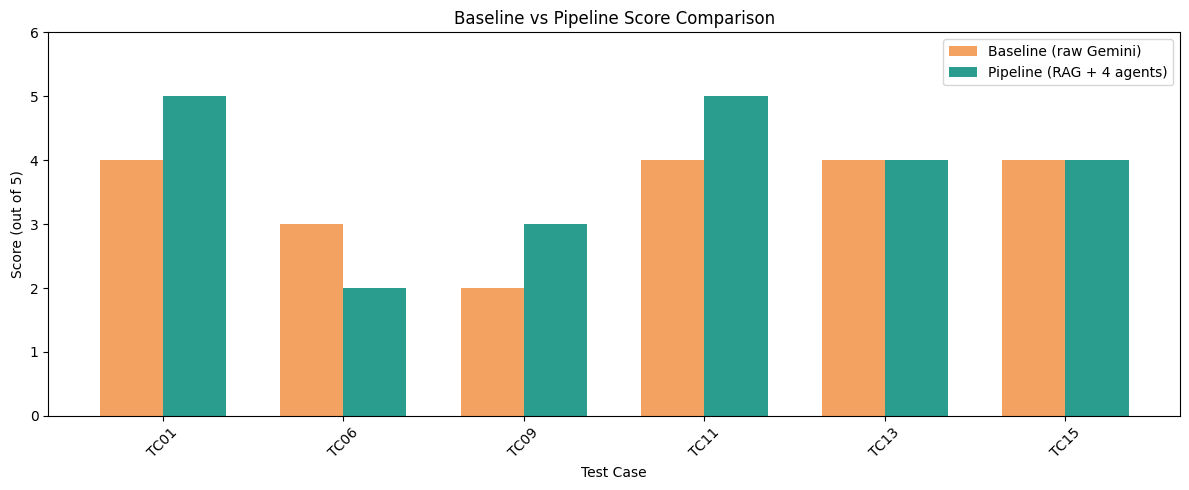

Average baseline score: 3.50/5
Average pipeline score: 3.83/5
Pipeline outperformed baseline on 3/6 test cases


In [26]:
import matplotlib.pyplot as plt
import numpy as np

ids = [r["id"] for r in results_summary]
baseline_scores = [r["baseline_total"] for r in results_summary]
pipeline_scores = [r["pipeline_total"] for r in results_summary]

x = np.arange(len(ids))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(x - width/2, baseline_scores, width, label="Baseline (raw Gemini)", color="#f4a261")
ax.bar(x + width/2, pipeline_scores, width, label="Pipeline (RAG + 4 agents)", color="#2a9d8f")

ax.set_xlabel("Test Case")
ax.set_ylabel("Score (out of 5)")
ax.set_title("Baseline vs Pipeline Score Comparison")
ax.set_xticks(x)
ax.set_xticklabels(ids, rotation=45)
ax.set_ylim(0, 6)
ax.legend()

plt.tight_layout()
plt.savefig("baseline_vs_pipeline.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Average baseline score: {np.mean(baseline_scores):.2f}/5")
print(f"Average pipeline score: {np.mean(pipeline_scores):.2f}/5")
print(f"Pipeline outperformed baseline on {pipeline_wins}/{len(results_summary)} test cases")